In [36]:
# Bibliothèques
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
from keras_facile import *


## Couches de neurones
Nous allons définir l’architecture d’un réseau très simple, en le décrivant couche par couche.

In [37]:
# Architecture du réseau
modele = Sequential()

# Couches de neurones
modele.add(
    Dense(2, input_dim=1, activation="relu")
)  # Couche d'entrée avec 2 entrées et 3 neurones
modele.add(Dense(1, input_dim=2, activation="relu"))
modele.summary()

/home/kmanu/master_ml/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

## Explications

* Notre réseau s’appelle **`modele`**. Il est de type **`Sequential`**, c’est-à-dire qu’il est constitué d’une **suite de couches** ajoutées les unes après les autres.

* Chaque couche est ajoutée à la précédente avec la commande :

  ```python
  modele.add()
  ```

  L’ordre d’ajout est donc **important**.

* Pour ajouter une couche, on utilise :

  ```python
  modele.add(Dense(nb_neurones, activation=ma_fonction))
  ```

  Une couche de type `Dense` signifie que **chaque neurone de la nouvelle couche est connecté à toutes les sorties des neurones de la couche précédente**.

---

### Caractéristiques des couches

* Pour chaque couche, il faut **préciser le nombre de neurones** qu’elle contient.
  S’il y a `n` neurones, alors la couche renvoie `n` valeurs en sortie.
  On rappelle qu’un **neurone transmet la même valeur de sortie à tous les neurones de la couche suivante**.

* Pour la **première couche**, il faut également indiquer le **nombre de valeurs en entrée** à l’aide du paramètre `input_dim=...`.
  Par exemple, si l’entrée est constituée d’une seule variable :

  ```python
  modele.add(Dense(nb_neurones, activation=..., input_dim=1))
  ```

* Pour les **autres couches**, le nombre d’entrées est automatiquement égal au **nombre de sorties de la couche précédente**. Il **n’est donc pas nécessaire de le préciser**.

* Il faut aussi **spécifier une fonction d’activation** pour chaque couche (la même pour tous les neurones d’une même couche).
  Parmi les fonctions prédéfinies, on trouve :

  * `'relu'` (ReLU)
  * `'sigmoid'` (σ)
  * `'linear'` (identité)

---

### Structure de l’exemple

* Le réseau ne possède **qu’une seule entrée**, et la **dernière couche contient un seul neurone**, ce qui donne **une seule valeur en sortie**.
  Le réseau définit donc une fonction :

  $$
  F : \mathbb{R} \rightarrow \mathbb{R}, \quad x \mapsto F(x)
  $$

---

### Remarque

* À ce stade, il ne s’agit que d’un **modèle de réseau** : les **poids ne sont pas encore fixés**.

* Pour vérifier que la structure est correcte, on peut exécuter la commande :

  ```python
  modele.summary()
  ```
  Elle affiche un **résumé des couches** et du **nombre de poids à apprendre**.


## Les poids
Lors de la définition d’un réseau et de la structure de ses couches, des poids aléatoires sont attribués à
chaque neurone. La démarche habituelle est ensuite d’entraîner le réseau, automatiquement, afin qu’il
trouve de « bons » poids. Mais pour l’instant, nous continuons de fixer les poids de chaque neurone à la
main.
La commande pour fixer les poids est set_weights().

In [38]:
# Couche 0
coeff = np.array([[1.0, -0.5]])
biais = np.array([-1, 1])
poids = [coeff, biais]
modele.layers[0].set_weights(poids)

# Couche 1
coeff = np.array([[1.0], [1.0]])
biais = np.array([0])
poids = [coeff, biais]
modele.layers[1].set_weights(poids)

Voici quelques précisions concernant la commande set_weights(). Son utilisation n’est pas très aisée.
• Les poids sont définis pour tous les éléments d’une couche, par une commande set_weights(poids).
• Les poids sont donnés sous la forme d’une liste : poids = [coeff,biais].
• Les biais sont donnés sous la forme d’un vecteur de biais (un pour chaque neurone).
• Les coefficients sont donnés sous la forme d’un tableau à deux dimensions. Ils sont définis par entrée.
Attention, la structure n’est pas naturelle (nous y reviendrons).
Pour vérifier que les poids d’une couche sont corrects, on utilise la commande get_weights(), par exemple
pour la première couche :
modele.layers[0].get_weights()
Cette instruction renvoie les poids sous la forme d’une liste [coefficients,biais] du type :
[ [[ 1. -0.5]], [-1. 1.] ]

Astuce! Cette commande est aussi très pratique avant même de fixer les poids, pour savoir quelle est la
forme que doivent prendre les poids afin d’utiliser set_weights().


## Evaluations
Comment utiliser le réseau ? C’est très simple avec predict(). Notre réseau définit une fonction x 7→ F(x).
L’entrée correspond donc à un réel et la sortie également. Voici comment faire :
entree = np.array([[3.0]])
sortie = modele.predict(entree)
Ici sortie vaut [[2.0]] et donc F(3) = 2. Ce que l’on peut vérifier à la main en calculant les sorties de
chaque neurone.

In [39]:
entree = np.array([[3.0]])
sortie = modele.predict(entree)
print(f"F(3) = {sortie}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
F(3) = [[2.]]


## Visualisation
Afin de tracer le graphe de la fonction F : R → R, on peut calculer d’autres valeurs :


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


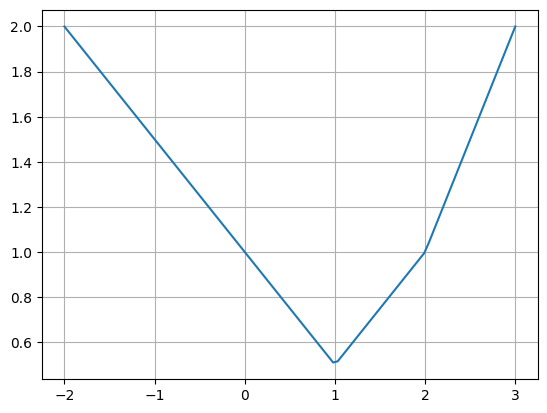

In [40]:
import matplotlib.pyplot as plt

liste_x = np.linspace(-2, 3, num=100)
entree = np.array([[x] for x in liste_x])
sortie = modele.predict(entree)
liste_y = np.array([y[0] for y in sortie])
plt.plot(liste_x, liste_y)
plt.grid()
plt.show()

# Plus d'entrées

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
F(7,-5) = 0.12303182482719421
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


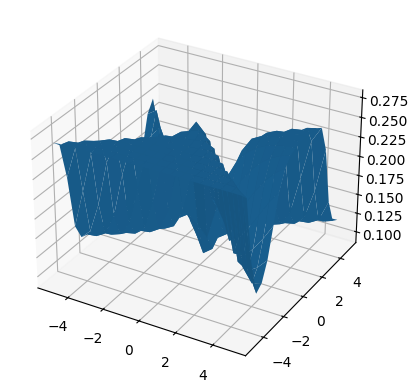

In [41]:
# Architecture du réseau
modele = Sequential()

# Couches de neurones
modele.add(Dense(3, input_dim=2, activation="sigmoid"))
modele.add(Dense(1, activation="sigmoid"))


# Couche 0
coeff = np.array([[1.0, 3.0, -5.0], [2.0, -4.0, -6.0]])
biais = np.array([-1.0, 0.0, 1.0])
poids = [coeff, biais]
modele.layers[0].set_weights(poids)

# Couche 1
coeff = np.array([[1.0], [1.0], [1.0]])
biais = np.array([-3.0])
poids = [coeff, biais]
modele.layers[1].set_weights(poids)

# Evaluation du modèle
entree = np.array([[7, -5]])
sortie = modele.predict(entree)
print(f"F(7,-5) = {sortie[0][0]}")

# Visualisation
VX = np.linspace(-5, 5, 20)
VY = np.linspace(-5, 5, 20)
X, Y = np.meshgrid(VX, VY)
entree = np.c_[X.ravel(), Y.ravel()]
sortie = modele.predict(entree)
Z = sortie.reshape(X.shape)
fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot_surface(X, Y, Z)
plt.show()

Remarquez que les poids ne sont pas définis neurone par neurone, mais par entrée : d’abord les poids de la
première entrée pour chaque neurone, puis les poids de la seconde entrée pour chaque neurone, etc